In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

BASE_DIR = Path("/Users/dhanistha/mutual-fund-analytics")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
CHART_DIR = BASE_DIR / "reports" / "charts"

CHART_DIR.mkdir(parents=True, exist_ok=True)

TRADING_DAYS = 252

In [2]:
fund_master = pd.read_csv(PROCESSED_DIR / "01_fund_master_clean.csv")
nav = pd.read_csv(PROCESSED_DIR / "02_nav_history_clean.csv")
transactions = pd.read_csv(PROCESSED_DIR / "08_investor_transactions_clean.csv")
performance = pd.read_csv(PROCESSED_DIR / "07_scheme_performance_clean.csv")
holdings = pd.read_csv(PROCESSED_DIR / "09_portfolio_holdings_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
holdings["portfolio_date"] = pd.to_datetime(holdings["portfolio_date"])

print("fund_master:", fund_master.shape)
print("nav:", nav.shape)
print("transactions:", transactions.shape)
print("performance:", performance.shape)
print("holdings:", holdings.shape)

fund_master: (40, 15)
nav: (64320, 3)
transactions: (32778, 16)
performance: (40, 21)
holdings: (322, 8)


In [3]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

returns = nav.dropna(subset=["daily_return"]).copy()

returns["daily_return"].describe()

count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64

In [4]:
var_rows = []

for amfi_code, group in returns.groupby("amfi_code"):
    daily_ret = group["daily_return"].dropna()

    var_95 = np.percentile(daily_ret, 5)
    cvar_95 = daily_ret[daily_ret <= var_95].mean()

    var_rows.append({
        "amfi_code": amfi_code,
        "var_95": var_95,
        "cvar_95": cvar_95,
        "mean_daily_return": daily_ret.mean(),
        "daily_volatility": daily_ret.std(),
        "observations": len(daily_ret)
    })

var_cvar_report = pd.DataFrame(var_rows)

var_cvar_report = var_cvar_report.merge(
    fund_master[["amfi_code", "fund_house", "scheme_name", "risk_category"]],
    on="amfi_code",
    how="left"
)

var_cvar_report = var_cvar_report.sort_values("var_95")

var_cvar_report.to_csv(PROCESSED_DIR / "var_cvar_report.csv", index=False)

var_cvar_report.head(10)

,amfi_code,var_95,cvar_95,mean_daily_return,daily_volatility,observations,fund_house,scheme_name,risk_category
4,101207,-0.023915,-0.030289,0.000303,0.013741,1607,Aditya Birla Sun Life MF,ABSL Small Cap Fund - Regular - Growth,Very High
17,119095,-0.023284,-0.029690,0.000130,0.013351,1607,Axis Mutual Fund,Axis Small Cap Fund - Regular - Growth,Very High
22,119599,-0.023155,-0.030163,0.000144,0.013289,1607,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Very High
11,118634,-0.022810,-0.029940,0.000506,0.013447,1607,Nippon India MF,Nippon India Small Cap Fund - Regular - Growth,Very High
39,149324,-0.021520,-0.028573,0.000854,0.013241,1607,DSP Mutual Fund,DSP Small Cap Fund - Regular - Growth,Very High
21,119598,-0.021502,-0.028444,0.000859,0.013401,1607,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Very High
16,119094,-0.016997,-0.022375,0.000734,0.010347,1607,Axis Mutual Fund,Axis Midcap Fund - Regular - Growth,High
29,120842,-0.016950,-0.021251,0.000223,0.009532,1607,Kotak Mahindra MF,Kotak Emerging Equity Fund - Regular - Growth,High
2,100033,-0.016902,-0.021850,0.000772,0.010097,1607,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High
7,102886,-0.016857,-0.021771,0.000079,0.009659,1607,UTI Mutual Fund,UTI Mid Cap Fund - Regular - Growth,High


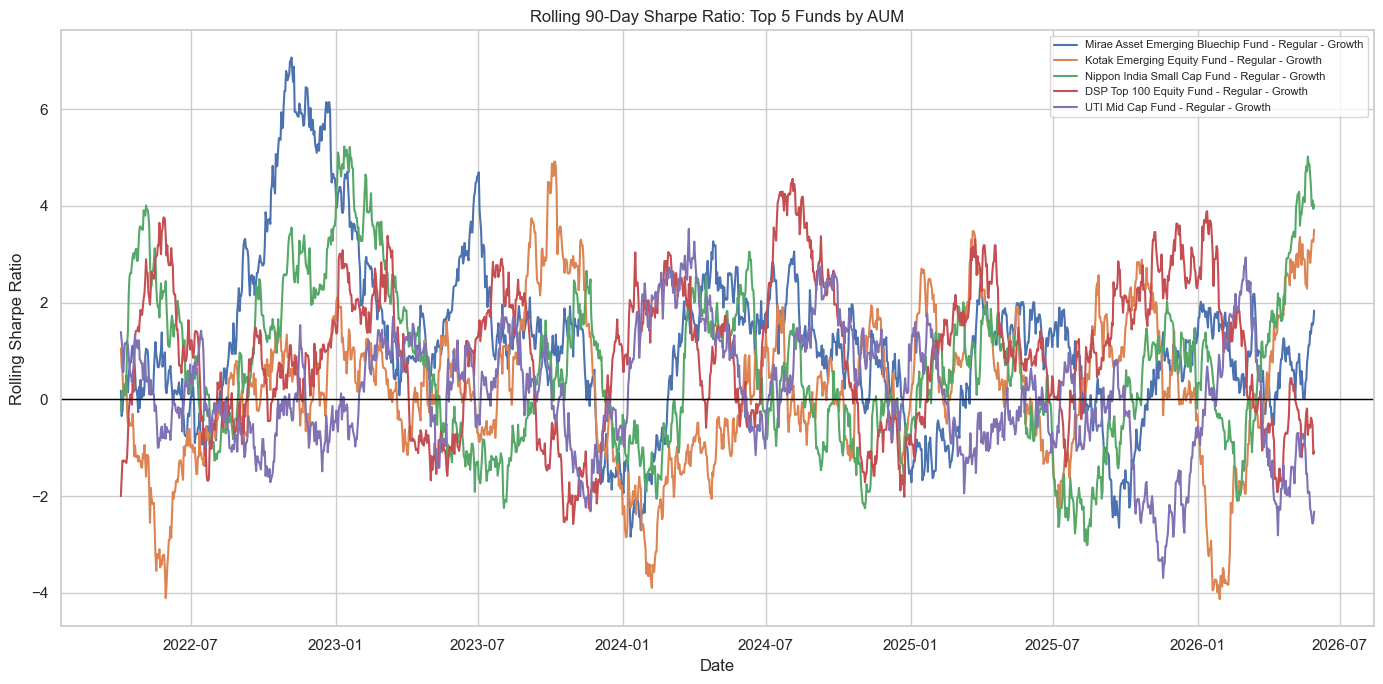

In [5]:
nav_pivot = nav.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
).sort_index()

return_pivot = nav_pivot.pct_change()

rolling_sharpe = (
    return_pivot.rolling(90).mean() /
    return_pivot.rolling(90).std()
) * np.sqrt(TRADING_DAYS)

top_5_codes = (
    performance.sort_values("aum_crore", ascending=False)
    .head(5)["amfi_code"]
    .tolist()
)

top_5_names = fund_master.set_index("amfi_code").loc[top_5_codes, "scheme_name"].to_dict()

plt.figure(figsize=(14, 7))

for code in top_5_codes:
    label = top_5_names.get(code, str(code))
    plt.plot(rolling_sharpe.index, rolling_sharpe[code], label=label)

plt.axhline(0, color="black", linewidth=1)
plt.title("Rolling 90-Day Sharpe Ratio: Top 5 Funds by AUM")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(CHART_DIR / "rolling_sharpe_chart.png", dpi=300)
plt.show()

In [6]:
transactions = transactions.sort_values(["investor_id", "transaction_date"])

first_txn = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
    .rename(columns={"transaction_date": "first_transaction_date"})
)

first_txn["cohort_year"] = first_txn["first_transaction_date"].dt.year

txn_cohort = transactions.merge(first_txn, on="investor_id", how="left")

sip_txn = txn_cohort[txn_cohort["transaction_type"] == "SIP"].copy()

avg_sip = (
    sip_txn.groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index()
    .rename(columns={"amount_inr": "avg_sip_amount"})
)

total_invested = (
    txn_cohort.groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index()
    .rename(columns={"amount_inr": "total_invested"})
)

fund_pref = (
    txn_cohort.groupby(["cohort_year", "amfi_code"])["amount_inr"]
    .sum()
    .reset_index()
)

fund_pref = fund_pref.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top_fund_pref = (
    fund_pref.sort_values(["cohort_year", "amount_inr"], ascending=[True, False])
    .groupby("cohort_year")
    .head(1)
    .rename(columns={"scheme_name": "top_fund_preference"})
)

cohort_report = (
    avg_sip
    .merge(total_invested, on="cohort_year", how="outer")
    .merge(top_fund_pref[["cohort_year", "top_fund_preference"]], on="cohort_year", how="left")
    .sort_values("cohort_year")
)

cohort_report


,cohort_year,avg_sip_amount,total_invested,top_fund_preference
0,2024,10996.885825,3491125187,UTI Nifty 50 Index Fund - Regular - Growth
1,2025,13505.209581,30455243,SBI Small Cap Fund - Direct Plan - Growth


/var/folders/75/97qxygvn0_53jt0d7p_28p680000gn/T/ipykernel_26221/4218811213.py:12: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


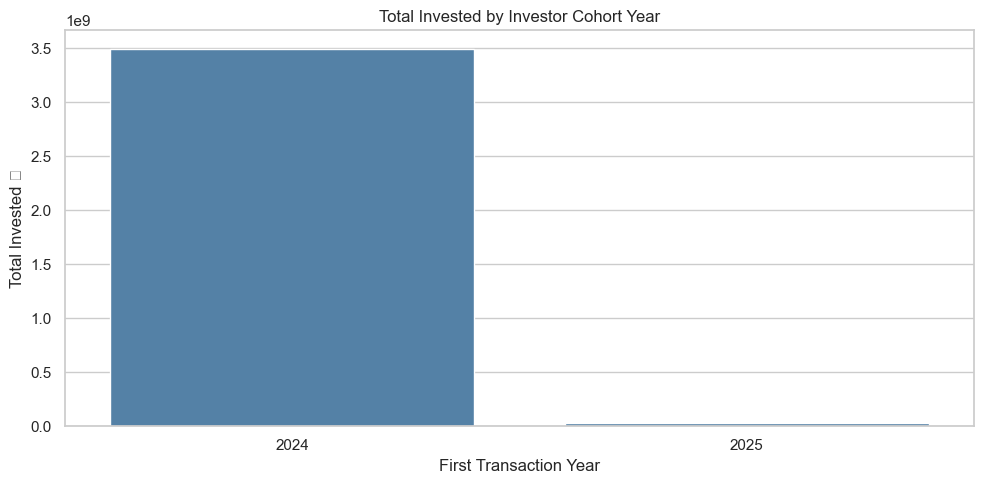

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=cohort_report,
    x="cohort_year",
    y="total_invested",
    color="steelblue"
)

plt.title("Total Invested by Investor Cohort Year")
plt.xlabel("First Transaction Year")
plt.ylabel("Total Invested ₹")
plt.tight_layout()
plt.show()

In [8]:
sip_only = transactions[transactions["transaction_type"] == "SIP"].copy()
sip_only = sip_only.sort_values(["investor_id", "transaction_date"])

sip_counts = (
    sip_only.groupby("investor_id")
    .size()
    .reset_index(name="sip_transaction_count")
)

eligible_investors = sip_counts[sip_counts["sip_transaction_count"] >= 6]["investor_id"]

sip_eligible = sip_only[sip_only["investor_id"].isin(eligible_investors)].copy()

sip_eligible["previous_sip_date"] = (
    sip_eligible.groupby("investor_id")["transaction_date"]
    .shift(1)
)

sip_eligible["gap_days"] = (
    sip_eligible["transaction_date"] - sip_eligible["previous_sip_date"]
).dt.days

continuity_report = (
    sip_eligible.groupby("investor_id")
    .agg(
        sip_transaction_count=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean"),
        max_gap_days=("gap_days", "max"),
        total_sip_amount=("amount_inr", "sum")
    )
    .reset_index()
)

continuity_report["sip_status"] = np.where(
    continuity_report["avg_gap_days"] > 35,
    "At-risk",
    "Regular"
)

continuity_rate = (
    (continuity_report["sip_status"] == "Regular").mean() * 100
)

print(f"SIP continuity rate: {continuity_rate:.2f}%")

continuity_report.head()

SIP continuity rate: 2.20%


,investor_id,sip_transaction_count,avg_gap_days,max_gap_days,total_sip_amount,sip_status
0,INV000004,6,85.400000,265.0,48256,At-risk
1,INV000008,6,70.400000,165.0,72853,At-risk
2,INV000010,6,64.800000,139.0,32183,At-risk
3,INV000011,7,40.166667,125.0,93920,At-risk
4,INV000012,8,57.000000,132.0,40139,At-risk


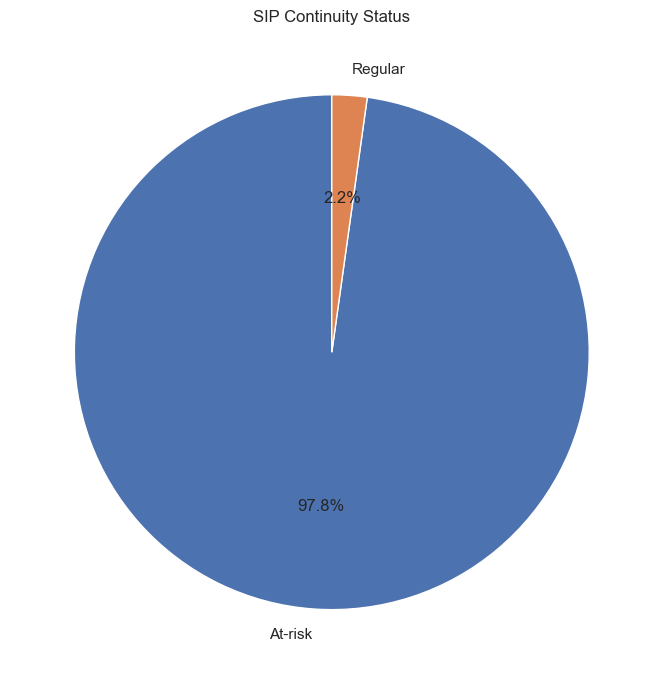

In [9]:
status_counts = continuity_report["sip_status"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("SIP Continuity Status")
plt.tight_layout()
plt.show()

In [10]:
equity_funds = fund_master[
    fund_master["category"].str.contains("Equity", case=False, na=False)
]["amfi_code"]

equity_holdings = holdings[holdings["amfi_code"].isin(equity_funds)].copy()

sector_weights = (
    equity_holdings.groupby(["amfi_code", "sector"])["weight_pct"]
    .sum()
    .reset_index()
)

sector_weights["weight_decimal"] = sector_weights["weight_pct"] / 100

hhi_report = (
    sector_weights.assign(weight_sq=sector_weights["weight_decimal"] ** 2)
    .groupby("amfi_code")["weight_sq"]
    .sum()
    .reset_index()
    .rename(columns={"weight_sq": "sector_hhi"})
)

hhi_report = hhi_report.merge(
    fund_master[["amfi_code", "fund_house", "scheme_name", "category", "sub_category"]],
    on="amfi_code",
    how="left"
)

hhi_report = hhi_report.sort_values("sector_hhi", ascending=False)

hhi_report.head(10)

,amfi_code,sector_hhi,fund_house,scheme_name,category,sub_category
11,119092,0.296769,Axis Mutual Fund,Axis Bluechip Fund - Regular - Growth,Equity,Large Cap
30,148569,0.254992,Mirae Asset MF,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,ELSS
27,125498,0.253155,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity,Mid Cap
6,102887,0.251383,UTI Mutual Fund,UTI Flexi Cap Fund - Regular - Growth,Equity,Flexi Cap
32,149323,0.241077,DSP Mutual Fund,DSP Midcap Fund - Regular - Growth,Equity,Mid Cap
21,120505,0.238695,ICICI Prudential MF,ICICI Pru Midcap Fund - Regular - Growth,Equity,Mid Cap
10,118635,0.237497,Nippon India MF,Nippon India ETF Nifty 50 BeES,Equity,Index/ETF
18,119599,0.232361,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap
22,120506,0.231464,ICICI Prudential MF,ICICI Pru Value Discovery Fund - Regular - Growth,Equity,Value
1,100033,0.227647,HDFC Mutual Fund,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap


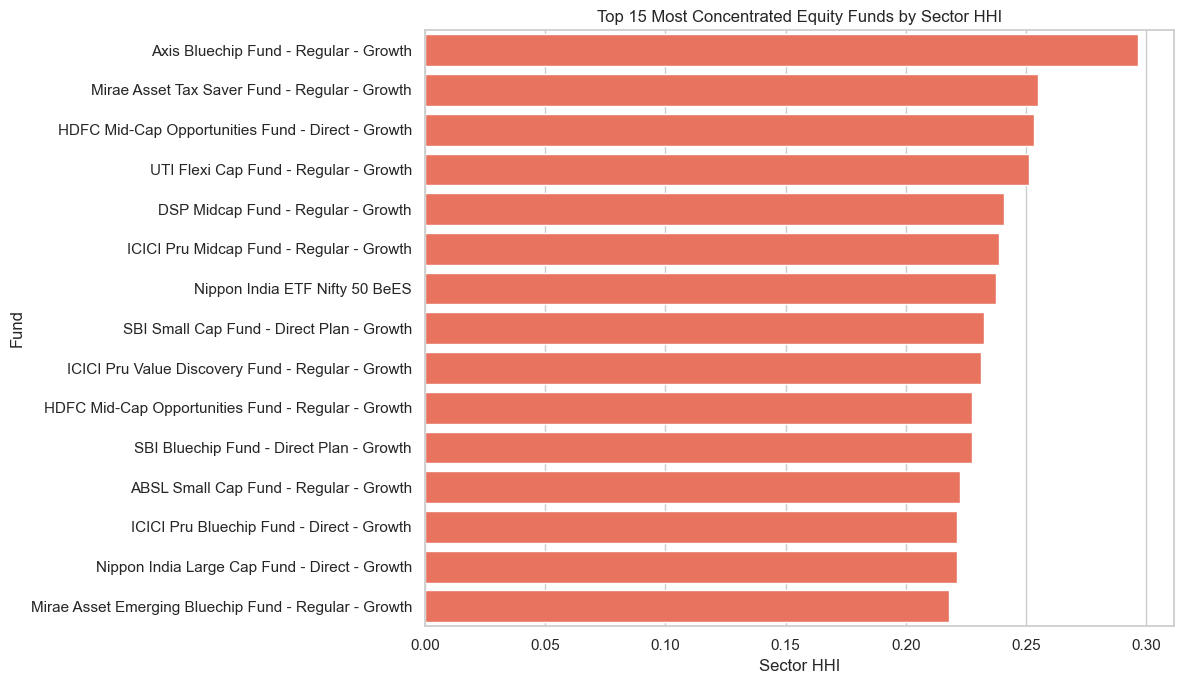

In [11]:
top_hhi = hhi_report.head(15)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_hhi,
    y="scheme_name",
    x="sector_hhi",
    color="tomato"
)

plt.title("Top 15 Most Concentrated Equity Funds by Sector HHI")
plt.xlabel("Sector HHI")
plt.ylabel("Fund")
plt.tight_layout()
plt.show()